In [1]:
%pip install pymysql
%pip install mysql-connector-python pandas
%pip install SQLAlchemy
%pip install load_dotenv
%pip install pandas
%pip install matplotlib
%pip install ipython-sql
%pip install scipy
%pip install ace_tools
%pip install seaborn
%pip install scikit-learn
%pip install graphviz
%pip install dtreeviz
%pip install dtreeviz scikit-learn graphviz matplotlib pandas

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [2]:
from dotenv import load_dotenv
import os
from IPython.display import display

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# Sleep

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

,SLEEP_START_CATEGORY,SLEEP_END_CATEGORY,WAKE_FEELING_CATEGORY,MINUTES_PER_DAY_CATEGORY,count
0,Early,Early,Good,None,1
1,Late,Early,Bad,None,1
2,Late,Early,Good,Acceptable,1
3,Late,Early,Good,Good,1
4,Late,Late,Good,Acceptable,2
5,Late,Late,Good,Good,3
6,Late,Late,Good,None,2


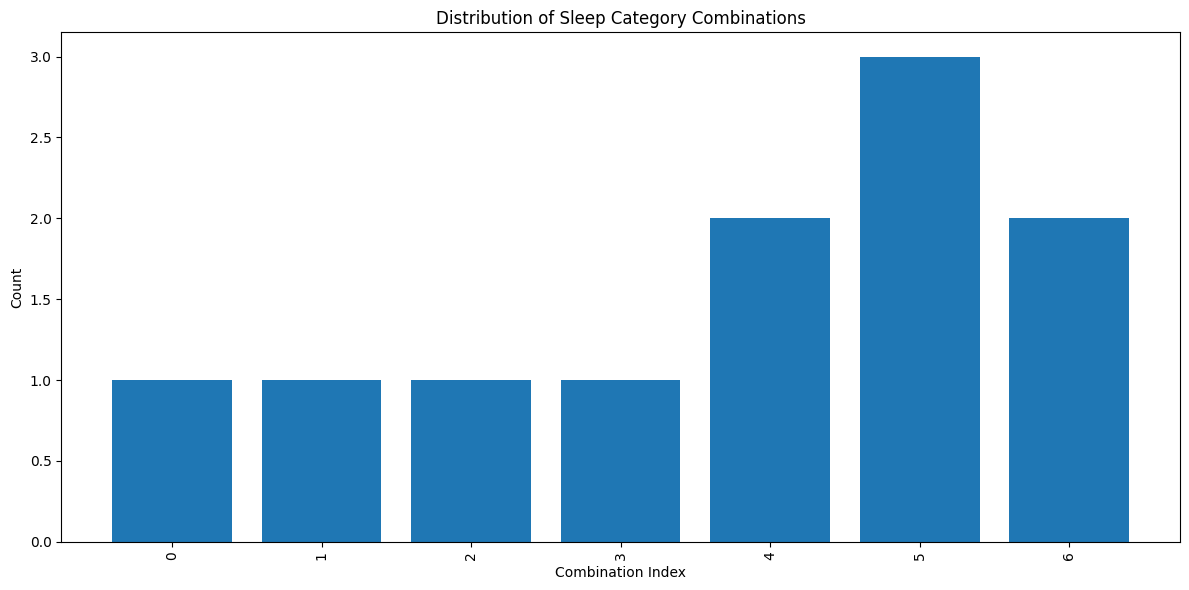

In [4]:
query = "SELECT * FROM ML_FOR_SLEEP"
df = pd.read_sql(query, engine)

combo_counts = df.groupby(
    [
        "SLEEP_START_CATEGORY",
        "SLEEP_END_CATEGORY",
        "WAKE_FEELING_CATEGORY",
        "MINUTES_PER_DAY_CATEGORY"
    ]
).size().reset_index(name="count")

display(combo_counts)

combo_counts["label"] = combo_counts.index.astype(str)

plt.figure(figsize=(12, 6))
plt.bar(combo_counts["label"], combo_counts["count"])
plt.xlabel("Combination Index")
plt.ylabel("Count")
plt.title("Distribution of Sleep Category Combinations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Sklearn

setting up

In [8]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

label_encoders = {}
for col in ["SLEEP_START_CATEGORY", "SLEEP_END_CATEGORY", "WAKE_FEELING_CATEGORY", "MINUTES_PER_DAY_CATEGORY"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df[["SLEEP_START_CATEGORY", "SLEEP_END_CATEGORY", "WAKE_FEELING_CATEGORY"]]
y = df["MINUTES_PER_DAY_CATEGORY"]

clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    random_state=42
)
# clf.fit(X, y)

Decision tree

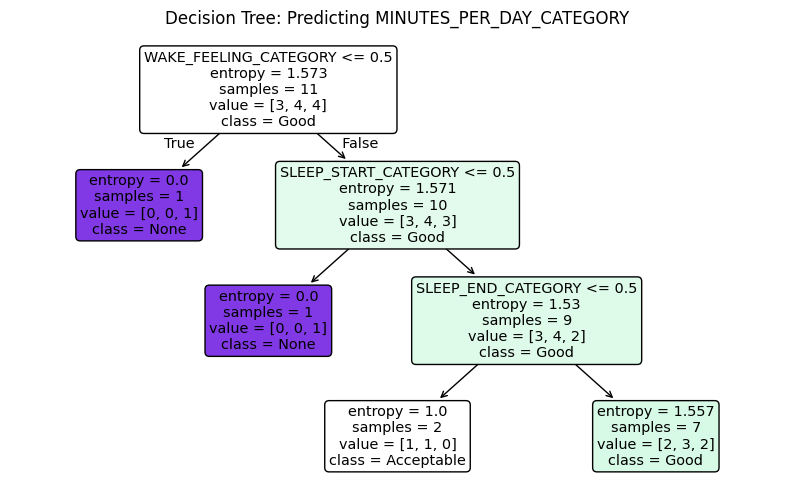

In [6]:
plt.figure(figsize=(10, 6))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=label_encoders["MINUTES_PER_DAY_CATEGORY"].classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree: Predicting MINUTES_PER_DAY_CATEGORY")
plt.show()

Predict from new data

In [7]:
sample = pd.DataFrame([["Late", "Late", "Good"]], columns=X.columns)
for col in sample.columns:
    sample[col] = label_encoders[col].transform(sample[col])

pred = clf.predict(sample)
print("Predicted:", label_encoders["MINUTES_PER_DAY_CATEGORY"].inverse_transform(pred)[0])

Predicted: Good
